In [6]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import scipy
import time
from scipy.interpolate import lagrange

from ader_dg_transport.ader_dg_2D.base_ader_dg_2D import BaseADERDG2D
from ader_dg_transport.ader_dg_2D.wave_ader_standard import WaveStandardAderDG2D
from ader_dg_transport.ader_dg_2D.wave_ader import WaveAderDG2D

In [13]:
xlim = 10.0
nx = 20
poly_order = 10 # 0.9, 0.6, 0.38
cfl = 0.1
solver = BaseADERDG2D(xlim, xlim, nx, nx, poly_order)

xs = solver.xs[:, :, 0]
ys = solver.ys[:, :, 0]
h0 = np.exp(-(xs - 5)**2 -(ys - 5)**2)

n = 15
lk_coeffs = {}

l_vals = []
k_vals = []
coeffs = []

for l in range(-n, n):
    k_coeffs = {}
    for k in range(-n, n):
        basis_function = np.exp(-1.0j * (l * xs + k * ys) * 2 * np.pi / solver.xlim)
        coeff = solver.integrate(basis_function * h0) / solver.xlim**2
    
        k_coeffs[k] = coeff

        l_vals.append(l)
        k_vals.append(k)
        coeffs.append(coeff)
    
    lk_coeffs[l] = k_coeffs

l_vals = np.array(l_vals)
k_vals = np.array(k_vals)
coeffs = np.array(coeffs)

In [39]:
def analytic_solution(solver, t=None):
    if t is None:
        t = solver.time
    w1 = np.sqrt(k_vals**2 + l_vals**2)
    w2 = -np.sqrt(k_vals**2 + l_vals**2)
    coeffs_ = 0.5 * coeffs * (np.exp(1.0j * w1 * t * 2 * np.pi / solver.xlim) + np.exp(1.0j * w2 * t * 2 * np.pi / solver.xlim))
    h_exact = (coeffs_[:, None, None, None, None] * basis_functions).sum(axis=0)
            
    return np.real(h_exact)

In [47]:
def run_solver(solver, nsteps, sample_rate=1):
    norm_list = [solver.norm(solver.u, solver.v, solver.h)]
    mass_list = [solver.integrate(solver.h)]
    error_list = [0.0]
    time_list = [0.0]

    for ii in range(nsteps):

        solver.time_step()

        if (ii % sample_rate) == 0:
        
            time_list.append(solver.time)
            
            norm_list.append(solver.norm(solver.u, solver.v, solver.h))
            
            mass_list.append(solver.integrate(solver.h))
            
            h_exact = analytic_solution(solver)
            error = np.sqrt(solver.integrate((solver.h - h_exact)**2) / solver.integrate(h_exact)**2)
            error_list.append(error)

    return time_list, mass_list, norm_list, error_list

In [69]:
nx = 10
poly_order = 5
c = 1.0
tend = 500.0

In [70]:
%%time
cfl = 0.2
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

solver = WaveAderDG2D(xlim, nx, poly_order=poly_order, c=c, dt=dt)

basis_functions = np.exp(-1.0j * (
    l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
) * 2 * np.pi / solver.xlim)

h0 = analytic_solution(solver, t=0)
solver.u[:] = 0.0
solver.v[:] = 0.0
solver.h[:] = h0

time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=1)

new_method_times = np.array(time_list)
new_method_norms = np.array(norm_list)
new_method_masses = np.array(mass_list)
new_method_errors = np.array(error_list)

CPU times: user 5min 27s, sys: 26.7 s, total: 5min 54s
Wall time: 46.3 s


In [71]:
%%time
cfl = 0.03
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

solver = WaveStandardAderDG2D(xlim, nx, poly_order=poly_order, c=c, dt=dt)

basis_functions = np.exp(-1.0j * (
    l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
) * 2 * np.pi / solver.xlim)

h0 = analytic_solution(solver, t=0)
solver.u[:] = 0.0
solver.v[:] = 0.0
solver.h[:] = h0

time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=6)

std_method_unstable_times = np.array(time_list)
std_method_unstable_norms = np.array(norm_list)
std_method_unstable_masses = np.array(mass_list)
std_method_unstable_errors = np.array(error_list)

CPU times: user 11min 18s, sys: 44.1 s, total: 12min 2s
Wall time: 1min 34s


In [72]:
%%time
cfl = 0.006
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

solver = WaveStandardAderDG2D(xlim, nx, poly_order=poly_order, c=c, dt=dt)

basis_functions = np.exp(-1.0j * (
    l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
) * 2 * np.pi / solver.xlim)

h0 = analytic_solution(solver, t=0)
solver.u[:] = 0.0
solver.v[:] = 0.0
solver.h[:] = h0

time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=30)

std_method_stable_times = np.array(time_list)
std_method_stable_norms = np.array(norm_list)
std_method_stable_masses = np.array(mass_list)
std_method_stable_errors = np.array(error_list)

CPU times: user 42min 35s, sys: 5min 16s, total: 47min 51s
Wall time: 6min 20s


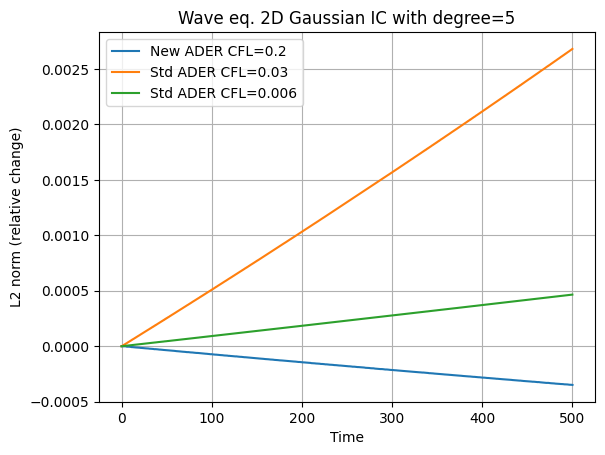

In [73]:
plt.title(f"Wave eq. 2D Gaussian IC with degree={solver.poly_order}")
plt.plot(
    new_method_times, 
    (new_method_norms - new_method_norms[0]) / new_method_norms[0],
    label='New ADER CFL=0.2'
)
plt.plot(
    std_method_unstable_times, 
    (std_method_unstable_norms - std_method_unstable_norms[0]) / std_method_unstable_norms[0],
    label='Std ADER CFL=0.03'
)
plt.plot(
    std_method_stable_times, 
    (std_method_stable_norms - std_method_stable_norms[0]) / std_method_stable_norms[0],
    label='Std ADER CFL=0.006'
)
        
plt.ylabel("L2 norm (relative change)")
plt.xlabel("Time")
plt.legend()
plt.grid()

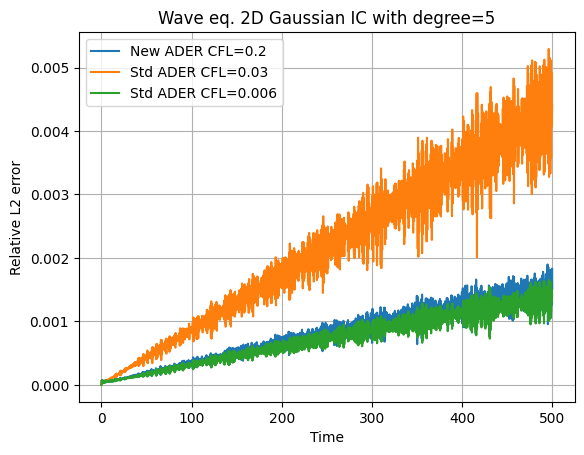

In [74]:
plt.title(f"Wave eq. 2D Gaussian IC with degree={solver.poly_order}")
plt.plot(
    new_method_times, 
    new_method_errors / new_method_norms[0], 
    label='New ADER CFL=0.2'
)
plt.plot(
    std_method_unstable_times, 
    std_method_unstable_errors / std_method_unstable_norms[0], 
    label='Std ADER CFL=0.03'
)
plt.plot(
    std_method_stable_times, 
    std_method_stable_errors / std_method_stable_norms[0], 
    label='Std ADER CFL=0.006'
)
plt.ylabel("Relative L2 error")
plt.xlabel("Time")
plt.legend()
plt.grid()

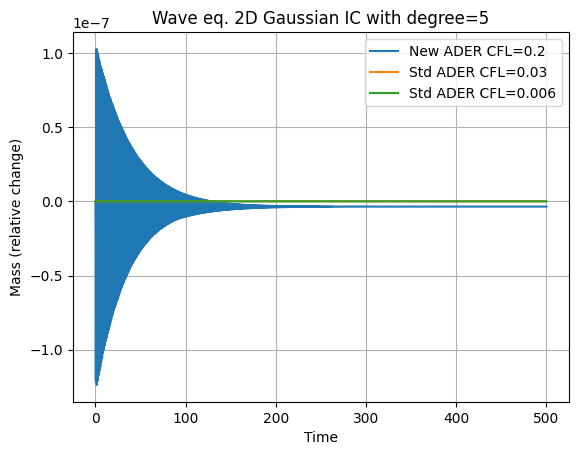

In [75]:
plt.title(f"Wave eq. 2D Gaussian IC with degree={solver.poly_order}")
plt.plot(
    new_method_times, 
    (new_method_masses - new_method_masses[0]) / new_method_masses[0], 
    label='New ADER CFL=0.2'
)
plt.plot(
    std_method_unstable_times, 
    (std_method_unstable_masses - std_method_unstable_masses[0]) / std_method_unstable_masses[0], 
    label='Std ADER CFL=0.03'
)
plt.plot(
    std_method_stable_times, 
    (std_method_stable_masses - std_method_stable_masses[0]) / std_method_stable_masses[0], 
    label='Std ADER CFL=0.006'
)
plt.ylabel("Mass (relative change)")
plt.xlabel("Time")
plt.legend()
plt.grid()